# Low-Hi-Super Resolution Simulation Visualization

## Modified network

This notebook demonstrates how to visualize N-body simulation data with different resolutions (low, high, super-resolution) from different bigfiles. This originates from the fact that the Zhang data had different kind of header compared to the output of the lr2srx2.py script. 

In [32]:
import visualize_lr
import visualize_hr
import visualize_sr
import numpy as np
import matplotlib.pyplot as plt

## Original simulation
Let's visualize the original simulation. In our current framework, we want to downsample the original simulation to a lower resolution and then use the lr2sr.py script to get the high-resolution simulation. This gives us the following workflow:
- Downsample the original simulation ($HR$) to a lower resolution ($LR$) (Ng 64 to 32 or $64^3$ to $32^3$ particles)
- Use the modified lr2sr.py script to get the super-resolution simulation ($SR$) (Ng 32 to 64 or $32^3$ to $64^3$ particles)
- Compare the three simulations ($LR$, $HR$, $SR$)



So from this simulation:

In [50]:
hr_path = "data/sim/PART_010"
hr_pos = visualize_hr.create_positions(hr_path, 100000, 64)


loading data/sim/PART_010 from bigfile
z=0.0 disp shape: (3, 64, 64, 64)
shape of hr_pos after dis2pos: (262144, 3)


[INFO] Using LaTeX for text rendering
[INFO] Saved figure to plot/hr_3d_Ng64.png


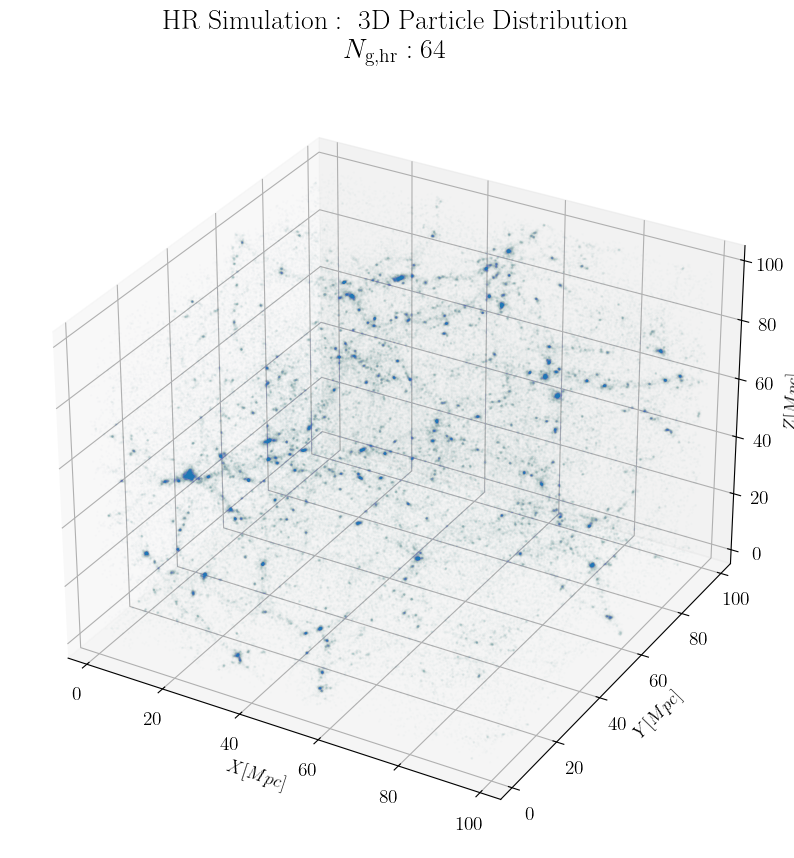

In [52]:
hr_params = {
    'Lbox': 100.0,
    'Ng_hr': 64,
    's': 0.8,
    'alpha': 0.008
}

visualize_hr.visualize_hr(hr_pos, **hr_params)

Now after downsampling the simulation ($64^3$ to $32^3$) to a lower resolution, we obtain the following visualization. 

In [55]:
lr_path = "data/sim_downsampled/PART_010_LR_32"
grid_size = visualize_lr.check_shape(lr_path)
print(f"Grid size: {grid_size}")

[INFO] Loading SR data from: data/sim_downsampled/PART_010_LR_32
[INFO] Loaded positions with shape: (32768, 3)
True Particle number is a cube number, its cubed root is 32
Grid size: 32


visualize_lr_3d takes 5 parameters:
- input_path: path to the low-resolution simulation data
- downsample_factor: the factor by which the simulation data is downsampled. If it is exactly the Ng of the simulation, the visualization will be the same as the original simulation.
- box_size: the size of the box in the simulation
- s: the size of the markers in the visualization
- alpha: the transparency of the markers in the visualization

The s and alpha are optional parameters, and the default values are 0.8 and 0.08 respectively. This is because when adding a lot of particles, the plot becomes too dense and the particles overlap. The s parameter is the size of the markers and the alpha parameter is the transparency of the markers.


[INFO] Using LaTeX for text rendering
[INFO] Loading SR data from: data/sim_downsampled/PART_010_LR_32
[INFO] Loaded positions with shape: (32768, 3)
[DEBUG] Position stats:
  - Shape: (32768, 3)
  - Range X: [0.00, 100.00]
  - Range Y: [0.00, 100.00]
  - Range Z: [0.00, 100.00]
[INFO] Sampled 32768  points for visualization. Sampling_size: True
[INFO] If it looks empty, it's because the alpha is too low for the number of particles
[INFO] Loading SR data from: data/sim_downsampled/PART_010_LR_32
[INFO] Loaded positions with shape: (32768, 3)
True Particle number is a cube number, its cubed root is 32
[INFO] Saved figure to plot/lr_3d_32_from_sim_lr32.png


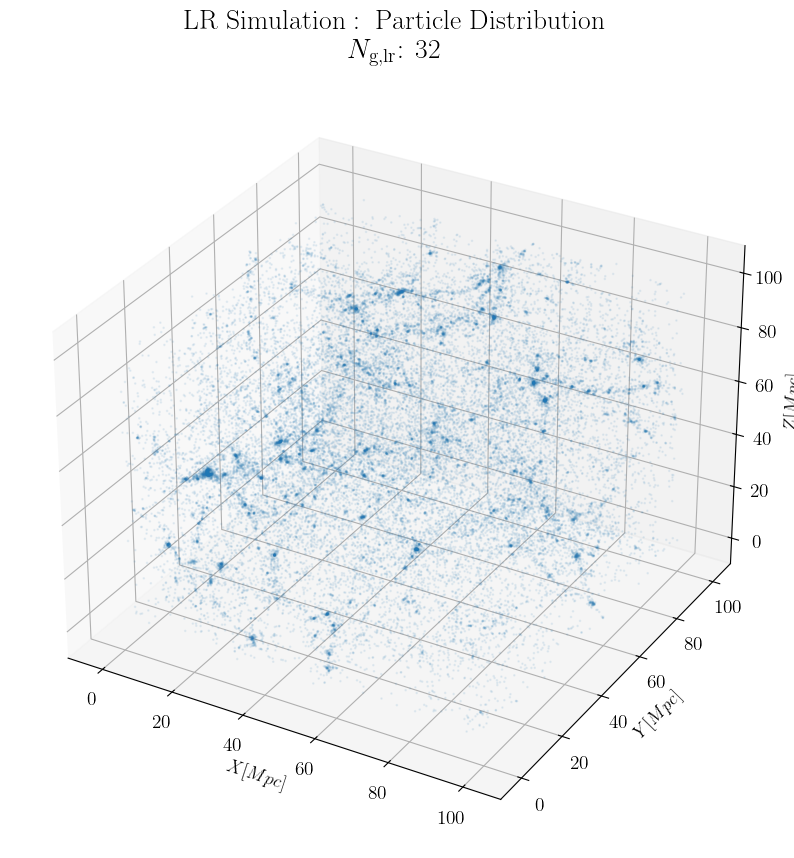

In [56]:
# Visualization settings
lr_params = {
    'downsample_factor': 32,
    's': 0.8,
    'alpha': 0.08,
    'box_size': 100.0
}

visualize_lr.visualize_lr_3d(lr_path,**lr_params)

Finally, we can use the lr2sr.py (or in this case the modified one) script to get the super-resolution simulation. This gives us the following visualization. 

In [59]:
sr_path = "output/SR/PART_010_LR_32_x2"
grid_size = visualize_sr.check_shape(sr_path)
print(f"Grid size: {grid_size}")


[INFO] Loading SR data from: output/SR/PART_010_LR_32_x2
[INFO] Loaded positions with shape: (262144, 3)
True Particle number is a cube number, its cubed root is 64
Grid size: 64


[INFO] Using LaTeX for text rendering
[INFO] Loading SR data from: output/SR/PART_010_LR_32_x2
[INFO] Loaded positions with shape: (262144, 3)
[DEBUG] Position stats:
  - Shape: (262144, 3)
  - Range X: [0.00, 100.00]
  - Range Y: [0.00, 100.00]
  - Range Z: [0.00, 103.37]
[INFO] Sampled 262144  points for visualization. Sampling_size: True
[INFO] If it looks empty, it's because the alpha is too low for the number of particles
[INFO] Loading SR data from: output/SR/PART_010_LR_32_x2
[INFO] Loaded positions with shape: (262144, 3)
True Particle number is a cube number, its cubed root is 64
[INFO] Saved figure to plot/sr_3d_64_from_sim_lr32.png


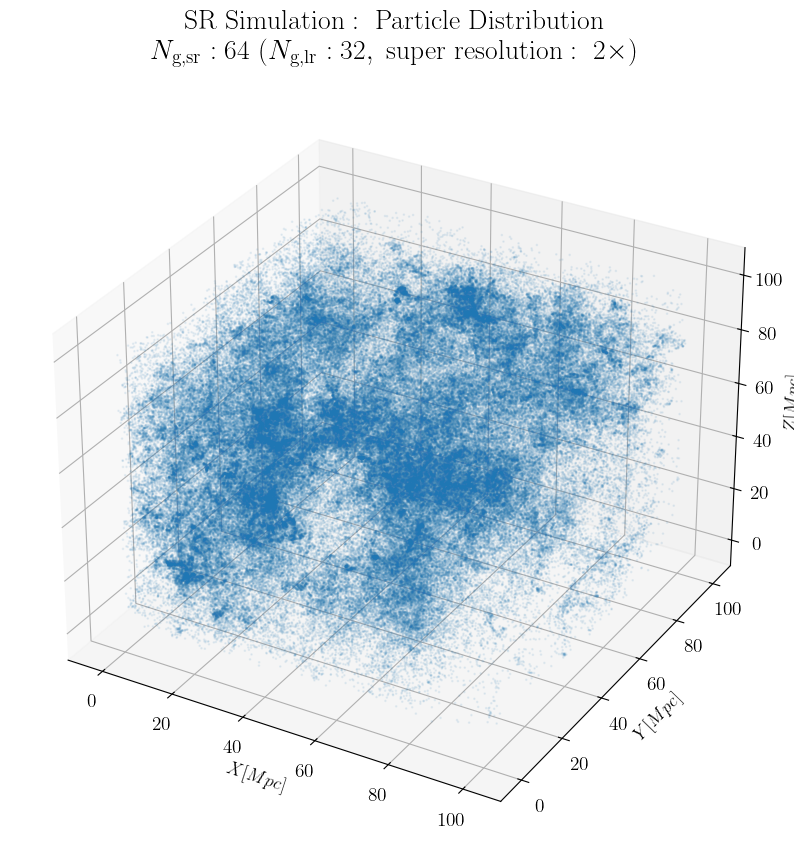

In [60]:
sr_params = {
    'downsample_factor': 64,
    'box_size': 100.0,
    's': 0.8,
    'alpha': 0.08
}
visualize_sr.visualize_sr_3d(sr_path,**sr_params)